In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm

from datetime import datetime, timedelta
import seaborn as sns

In [31]:
graph1_1 = pd.read_csv('data/VAR_42631_56896-odecty.csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]
graph1_2 = pd.read_csv('data/VAR_42631_56896-odecty (1).csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]
graph2 = pd.read_csv('data/VAR_41494_55419-odecty.csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]
graph3 = pd.read_csv('data/VAR_97467_124449-odecty.csv', sep=";")[['VAR_ID', 'Time of reading', 'Value', 'Diff.']]

In [32]:
def concatenate_datasets(df1, df2, output_file_path):
    try:
        concatenated_df = pd.concat([df1, df2], ignore_index=True)

        # Save the concatenated DataFrame to a new CSV file
        concatenated_df.to_csv(output_file_path, index=False)

        print(f"Successfully concatenated into '{output_file_path}'")
        print("\nInformation about the new concatenated dataset:")
        concatenated_df.info()

    except FileNotFoundError as e:
        print(f"Error: One of the files was not found. Please check the file paths.")
        print(f"Details: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


output_file = 'data/VAR_42631_56896-odecty-full.csv'

concatenate_datasets(graph1_1, graph1_2, output_file)
graph1 = pd.read_csv(output_file)

Successfully concatenated into 'data/VAR_42631_56896-odecty-full.csv'

Information about the new concatenated dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25258 entries, 0 to 25257
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VAR_ID           25258 non-null  int64  
 1   Time of reading  25258 non-null  object 
 2   Value            25258 non-null  float64
 3   Diff.            25256 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 789.4+ KB


In [33]:
display(graph1["Time of reading"].head())

0    2025-08-29 16:50:32.0
1    2025-08-29 16:30:32.0
2    2025-08-29 16:10:32.0
3    2025-08-29 15:30:32.0
4    2025-08-29 14:50:32.0
Name: Time of reading, dtype: object

In [34]:
def index_dataset(df, time_column):
    df[time_column] = pd.to_datetime(df[time_column])
    df.sort_values(time_column, inplace=True)
    df.set_index(time_column, inplace=True)
        
index_dataset(graph1, "Time of reading")
index_dataset(graph2, "Time of reading")
index_dataset(graph3, "Time of reading")

In [35]:
display(graph1.head(20))

,VAR_ID,Value,Diff.
Time of reading,,,
2024-08-29 00:12:00,56896,24185.53,NaN
2024-08-29 00:32:00,56896,24185.64,0.11
2024-08-29 00:52:00,56896,24185.67,0.03
2024-08-29 01:12:00,56896,24185.67,0.00
2024-08-29 01:32:00,56896,24185.68,0.01
2024-08-29 01:52:00,56896,24185.69,0.01
2024-08-29 02:12:00,56896,24185.70,0.01
2024-08-29 02:32:00,56896,24185.71,0.01
2024-08-29 02:52:00,56896,24185.71,0.00


In [36]:
def check_periodicity(df):
    """
    Checks for periodicity in a DataFrame's DateTimeIndex and prints a message if a
    periodic timestamp is missed.

    Args:
        df (pd.DataFrame): The DataFrame to check. Must have a DateTimeIndex.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        print("Error: DataFrame does not have a DateTimeIndex.")
        return

    # Ensure index is sorted
    df = df.sort_index()

    # Calculate time differences between consecutive rows
    time_diffs = df.index.to_series().diff()

    # Find the most common difference (periodicity)
    periodicity = time_diffs.mode()

    if periodicity.empty:
        print("Could not determine a consistent periodicity from the data.")
        return

    most_common_period = periodicity[0]
    print(f"\nDetermined a common periodicity of: {most_common_period}")

    # Find gaps larger than expected + tolerance
    missed_timestamps = time_diffs[time_diffs > most_common_period + pd.Timedelta(minutes=5)]
    missed_timestamps_num = len(missed_timestamps)

    if missed_timestamps_num > 0:
        print("\nMissed periodic timestamp(s) detected:")
        for index, diff in missed_timestamps.items():
            prev_timestamp = df.index[df.index.get_loc(index) - 1]
            current_timestamp = index
            # print(f"  - Gap of {diff} between {prev_timestamp} and {current_timestamp}")
        print(f"\nMissed {missed_timestamps_num} timestamps out of {len(df)} measurements.")
    else:
        print("\nNo missed periodic timestamps were detected.")

        
print("Periodicity for graph1:")
check_periodicity(graph1)
print("Periodicity for graph2:")
check_periodicity(graph2)
print("Periodicity for graph3:")
check_periodicity(graph3)

Periodicity for graph1:

Determined a common periodicity of: 0 days 00:20:00

Missed periodic timestamp(s) detected:

Missed 556 timestamps out of 25258 measurements.
Periodicity for graph2:

Determined a common periodicity of: 0 days 00:30:00

Missed periodic timestamp(s) detected:

Missed 26 timestamps out of 17267 measurements.
Periodicity for graph3:

Determined a common periodicity of: 0 days 00:30:02

Missed periodic timestamp(s) detected:

Missed 351 timestamps out of 16418 measurements.


In [37]:
def plot_timeseries(df, value_column, 
                   plot_type='line', 
                   sample_rate=None, 
                   date_range=None,
                   figsize=(15, 8),
                   highlight_filled=False,
                   filled_df=None,
                   title=None):
    """
    Plots time series data from a DataFrame with a DateTimeIndex.

    Args:
        df (pd.DataFrame): The DataFrame with time series data (must have DateTimeIndex)
        value_column (str): Name of the value column
        plot_type (str): 'line', 'scatter', 'both', or 'resampled'
        sample_rate (int): If provided, sample to at most this many points
        date_range (tuple): (start_date, end_date) to filter the data
        figsize (tuple): Figure size (width, height)
        highlight_filled (bool): Whether to highlight ARIMA-filled values
        filled_df (pd.DataFrame): DataFrame with filled values (if highlighting)
        title (str): Custom plot title

    Returns:
        matplotlib.figure.Figure
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame must have a DateTimeIndex")

    # Work on a copy
    df_plot = df.copy().sort_index()

    # Filter by date range
    if date_range:
        start_date, end_date = date_range
        df_plot = df_plot.loc[start_date:end_date]
        print(f"Filtered to date range: {len(df_plot)} points")

    # Downsample if requested
    if sample_rate and len(df_plot) > sample_rate:
        step = max(1, len(df_plot)//sample_rate)
        df_plot = df_plot.iloc[::step]
        print(f"Sampled to {len(df_plot)} points for faster plotting")

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    if title is None:
        title = f"Time Series Plot - {value_column} ({len(df_plot):,} points)"

    # Plot types
    if plot_type == 'line':
        ax.plot(df_plot.index, df_plot[value_column],
                linewidth=0.8, alpha=0.8, color='blue', label='Original Data')

    elif plot_type == 'scatter':
        ax.scatter(df_plot.index, df_plot[value_column],
                   s=1, alpha=0.6, color='blue', label='Original Data')

    elif plot_type == 'both':
        ax.plot(df_plot.index, df_plot[value_column],
                linewidth=0.5, alpha=0.7, color='blue', label='Line')
        ax.scatter(df_plot.index, df_plot[value_column],
                   s=0.5, alpha=0.5, color='red', label='Points')

    elif plot_type == 'resampled':
        df_resampled = df_plot[value_column].resample('H').mean()
        ax.plot(df_resampled.index, df_resampled,
                linewidth=1, color='blue', label='Hourly Average')
        print(f"Resampled to hourly averages: {len(df_resampled)} points")

    # Highlight filled values
    if highlight_filled and filled_df is not None:
        if not isinstance(filled_df.index, pd.DatetimeIndex):
            raise ValueError("filled_df must also have a DateTimeIndex")
        filled_copy = filled_df.copy().sort_index()

        # Find timestamps in filled_df but missing in df
        new_times = filled_copy.index.difference(df.index)

        if not new_times.empty:
            filled_only = filled_copy.loc[new_times]
            if date_range:
                start_date, end_date = date_range
                filled_only = filled_only.loc[start_date:end_date]

            if not filled_only.empty:
                ax.scatter(filled_only.index, filled_only[value_column],
                           s=3, color='red', alpha=0.8,
                           label='ARIMA Filled', zorder=5)
                print(f"Highlighted {len(filled_only)} filled values")

    # Labels and formatting
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel(value_column, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Stats box
    stats_text = f"""Statistics:
    Min: {df_plot[value_column].min():.2f}
    Max: {df_plot[value_column].max():.2f}
    Mean: {df_plot[value_column].mean():.2f}
    Std: {df_plot[value_column].std():.2f}"""
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round',
            facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()


In [38]:
def plot_timeseries_interactive_ranges(df, value_column, num_ranges=4):
    """
    Splits a large time series into multiple subplot ranges for exploration.

    Args:
        df (pd.DataFrame): DataFrame with DateTimeIndex
        value_column (str): Name of value column
        num_ranges (int): Number of subplots

    Returns:
        matplotlib.figure.Figure
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame must have a DateTimeIndex")

    df_plot = df.copy().sort_index()

    total_duration = df_plot.index.max() - df_plot.index.min()
    range_duration = total_duration / num_ranges

    fig, axes = plt.subplots(num_ranges, 1, figsize=(15, 3*num_ranges), sharey=True)
    if num_ranges == 1:
        axes = [axes]

    for i in range(num_ranges):
        start_time = df_plot.index.min() + i * range_duration
        end_time = start_time + range_duration
        range_data = df_plot.loc[start_time:end_time]

        if not range_data.empty:
            axes[i].plot(range_data.index, range_data[value_column],
                         linewidth=0.8, color='blue', alpha=0.8)
            axes[i].set_title(
                f'Range {i+1}: {start_time.strftime("%Y-%m-%d %H:%M")} → {end_time.strftime("%Y-%m-%d %H:%M")} '
                f'({len(range_data)} points)'
            )
            axes[i].grid(True, alpha=0.3)
            axes[i].set_ylabel(value_column)
            plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=45, ha='right')

    axes[-1].set_xlabel('Time')
    plt.tight_layout()
    return fig


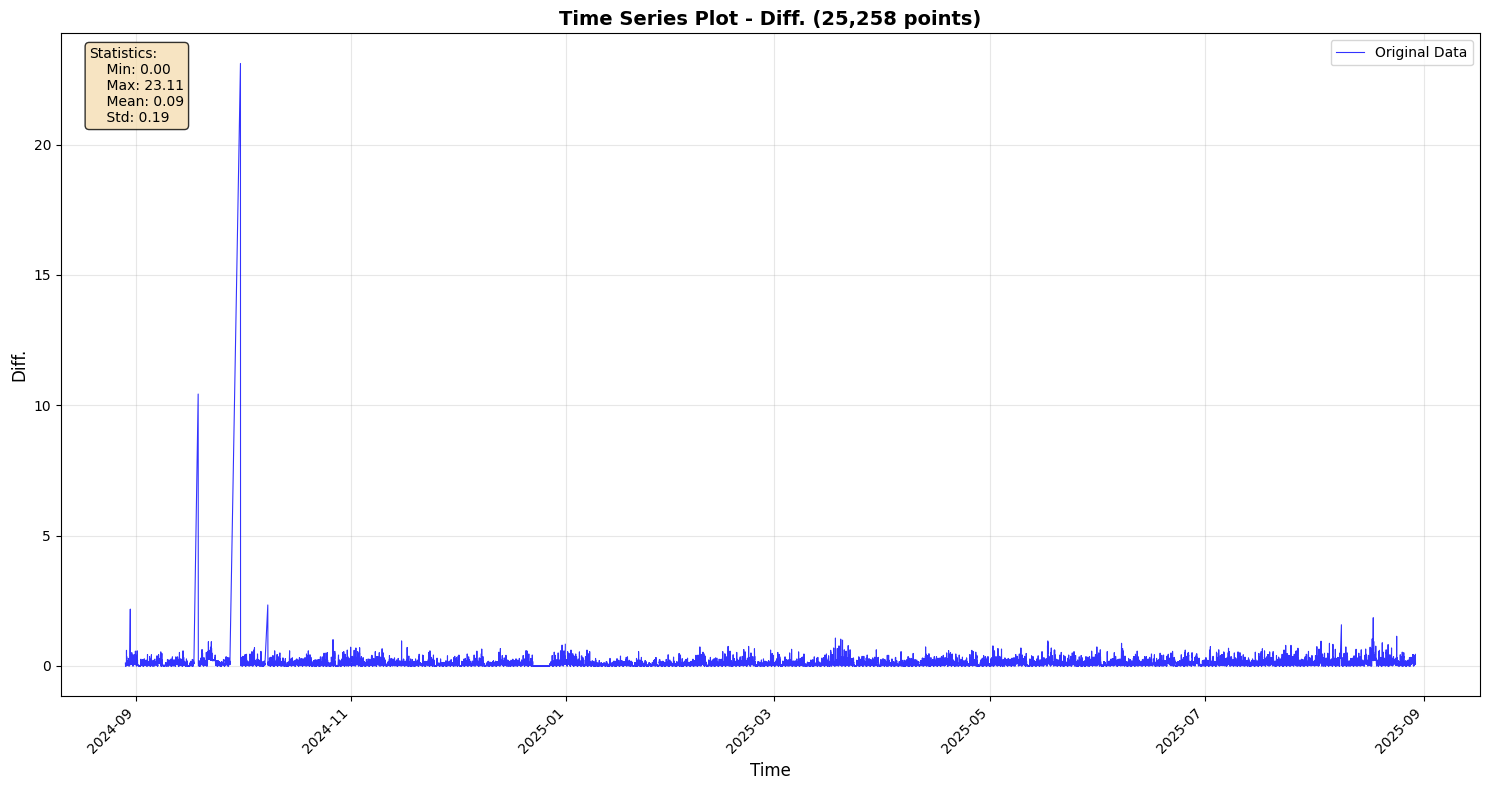

In [39]:
plot_timeseries(graph1, value_column="Diff.")

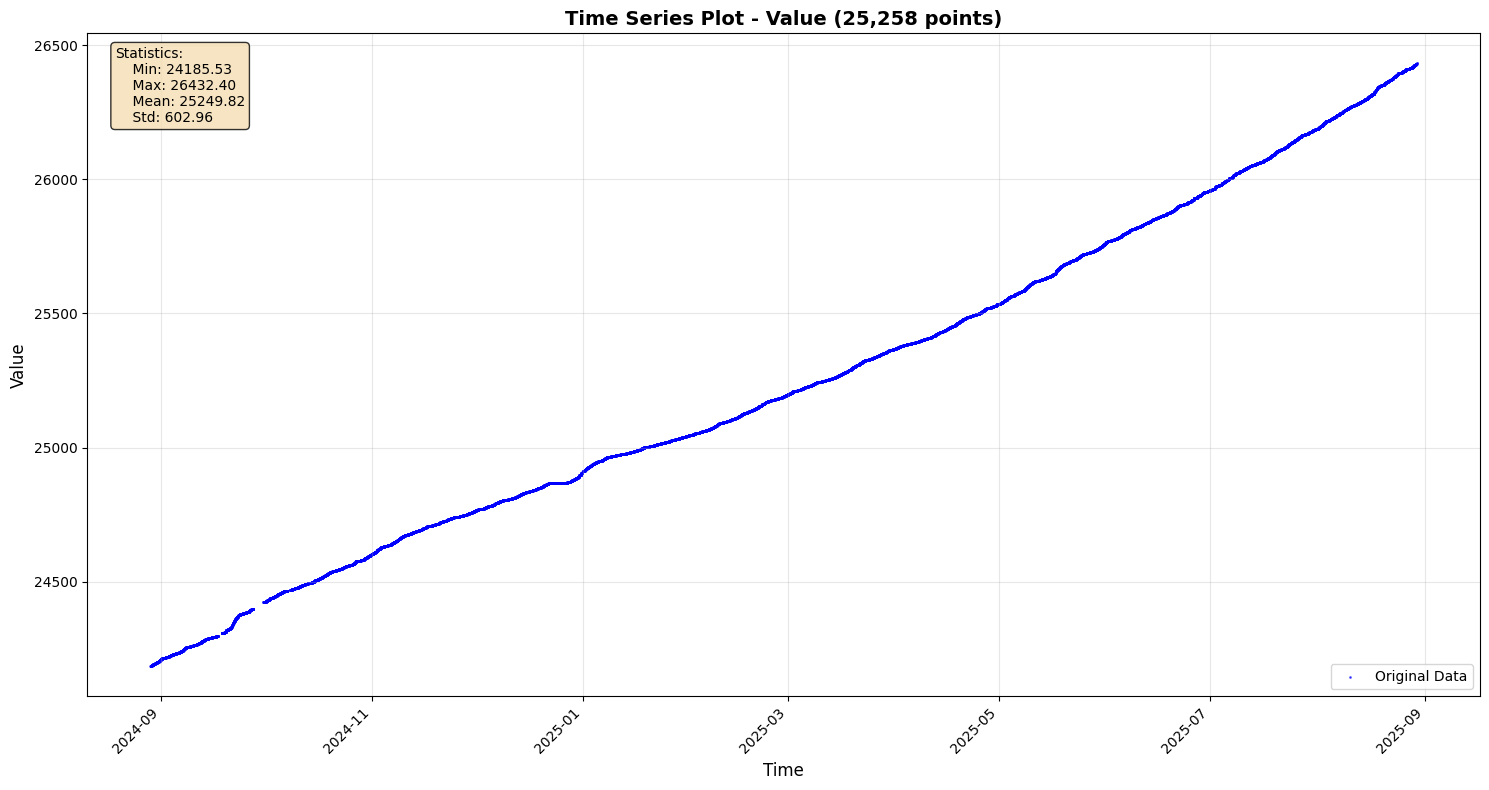

In [40]:
plot_timeseries(graph1, value_column="Value", plot_type="scatter")

Filtered to date range: 145 points


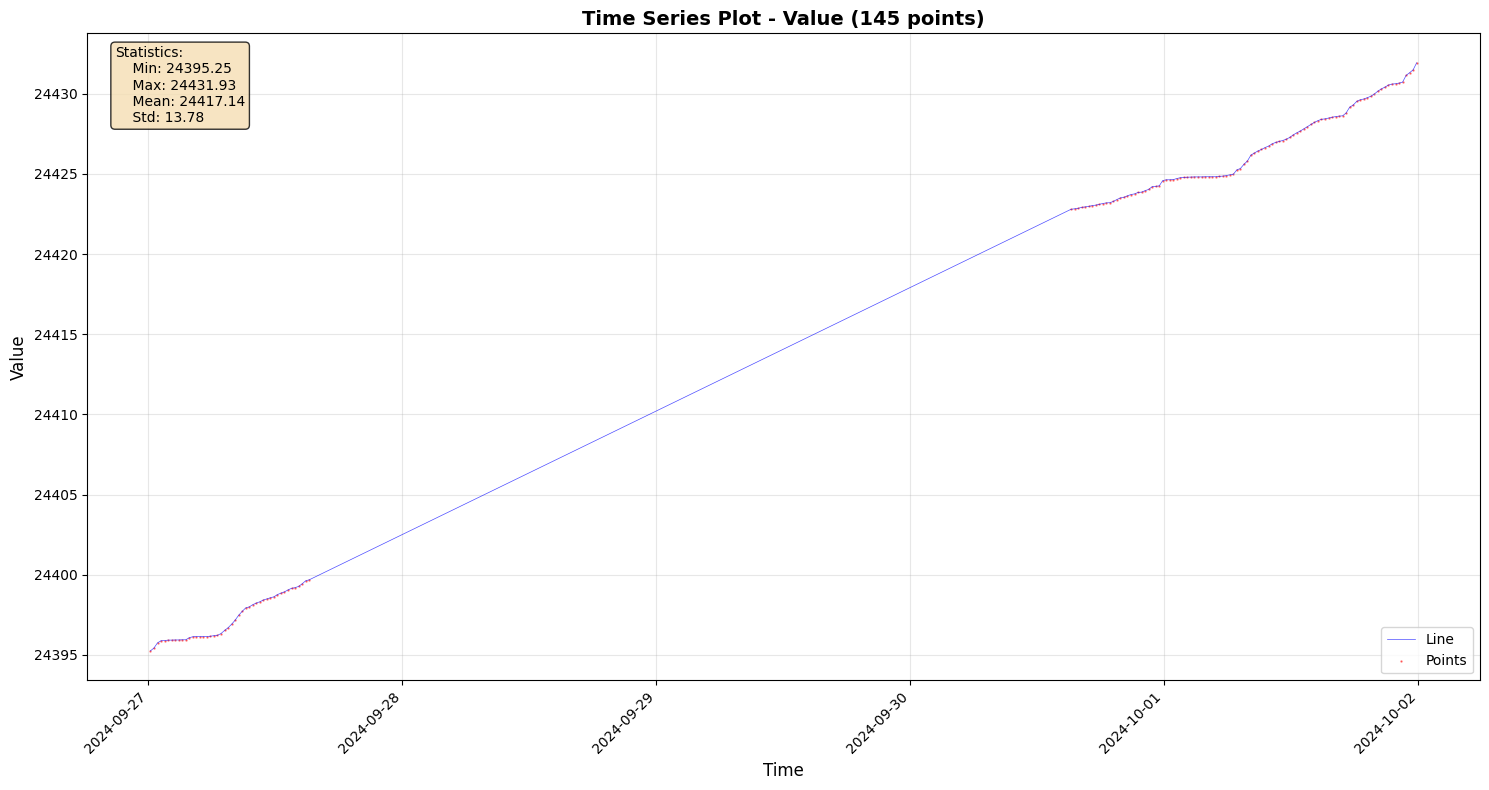

In [41]:
plot_timeseries(graph1, value_column="Value", date_range=("2024-09-27", "2024-10-1"), plot_type="both")

Filtered to date range: 145 points


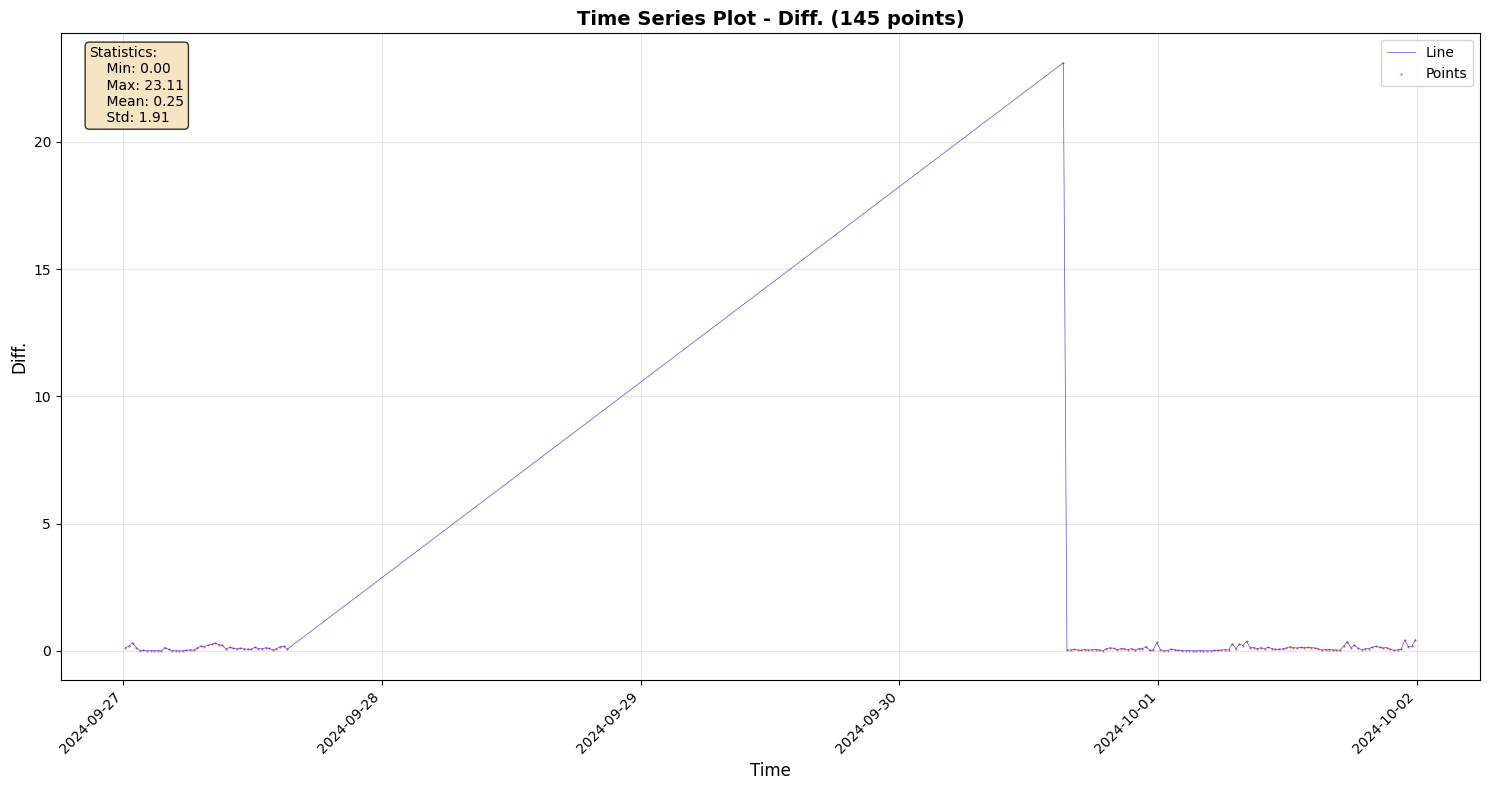

In [42]:
plot_timeseries(graph1, value_column="Diff.", date_range=("2024-09-27", "2024-10-1"), plot_type="both")

## Average per hour

In [43]:
import pandas as pd

def resample_to_hourly_averages(df, drop_empty_hours=True, fill_method=None):
    """
    Resample water meter data to hourly intervals with average values.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with datetime index (Time of reading) and columns 'Value' and 'Diff.'
    drop_empty_hours : bool, default True
        If True, removes hours with no data (all NaN values)
    fill_method : str or None, default None
        Method to fill missing hourly values: 'forward'/'ffill', 'backward'/'bfill', 'interpolate', None
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with hourly datetime index and averaged 'Value' and 'Diff.' columns
    """
    
    # Input validation
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame")
    
    required_columns = ['Value', 'Diff.']
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")
    
    # Ensure the index is datetime type
    if not isinstance(df.index, pd.DatetimeIndex):
        try:
            df.index = pd.to_datetime(df.index)
        except Exception as e:
            raise ValueError(f"Could not convert index to datetime: {e}")
    
    # Create a copy to avoid modifying the original
    df_copy = df[required_columns].copy()
    
    # Resample to hourly frequency and calculate mean
    hourly_df = df_copy.resample('h').mean()
    
    # Handle empty hours
    if drop_empty_hours:
        hourly_df = hourly_df.dropna(how='all')
    
    # Apply fill method if specified
    if fill_method in ['forward', 'ffill']:
        hourly_df = hourly_df.ffill()
    elif fill_method in ['backward', 'bfill']:
        hourly_df = hourly_df.bfill()
    elif fill_method == 'interpolate':
        hourly_df = hourly_df.interpolate(method='time')
    
    return hourly_df


In [44]:
hourly_df = resample_to_hourly_averages(graph1)

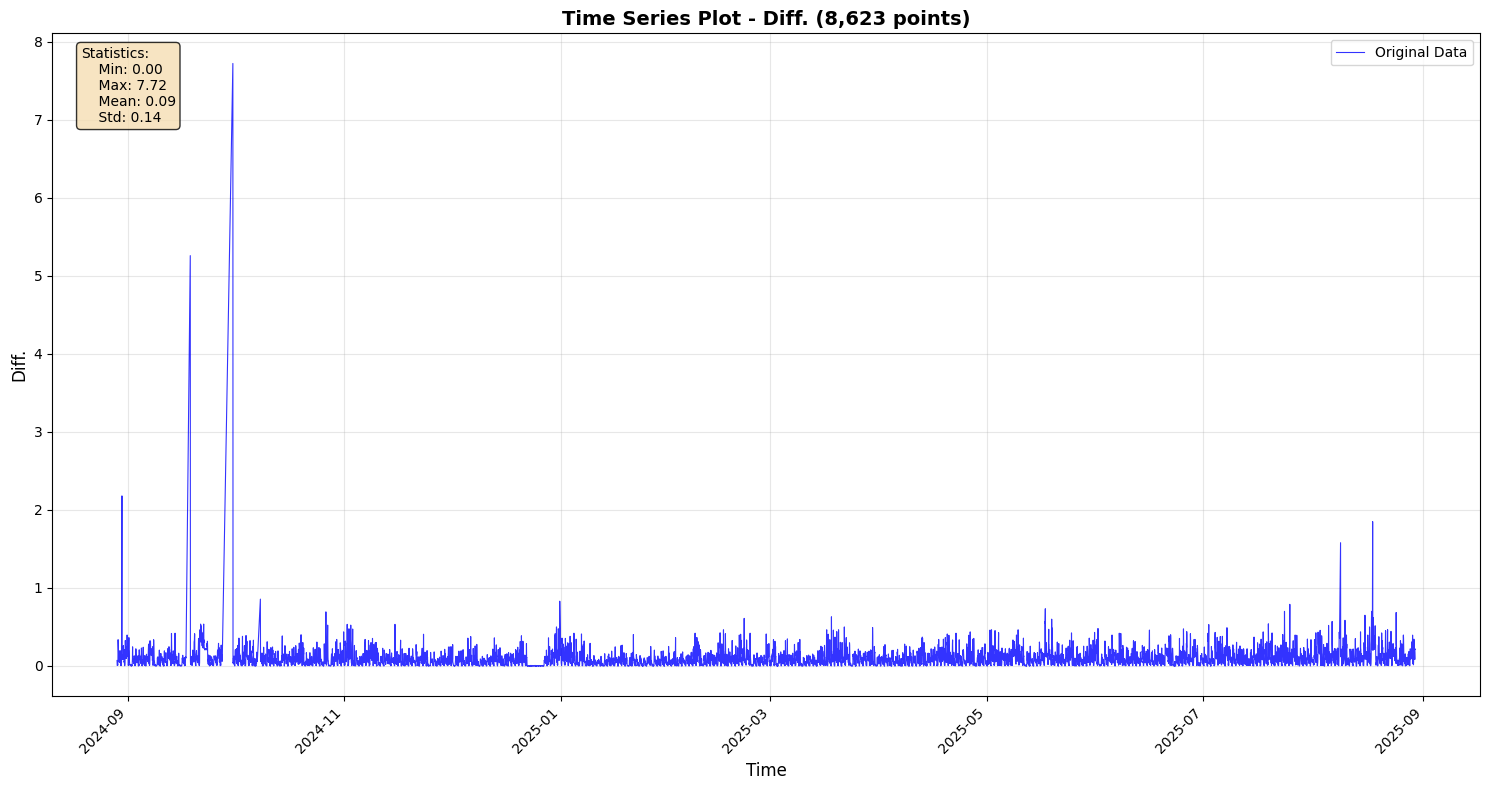

In [ ]:
plot_timeseries(hourly_df, value_column="Diff.", plot_type="line")

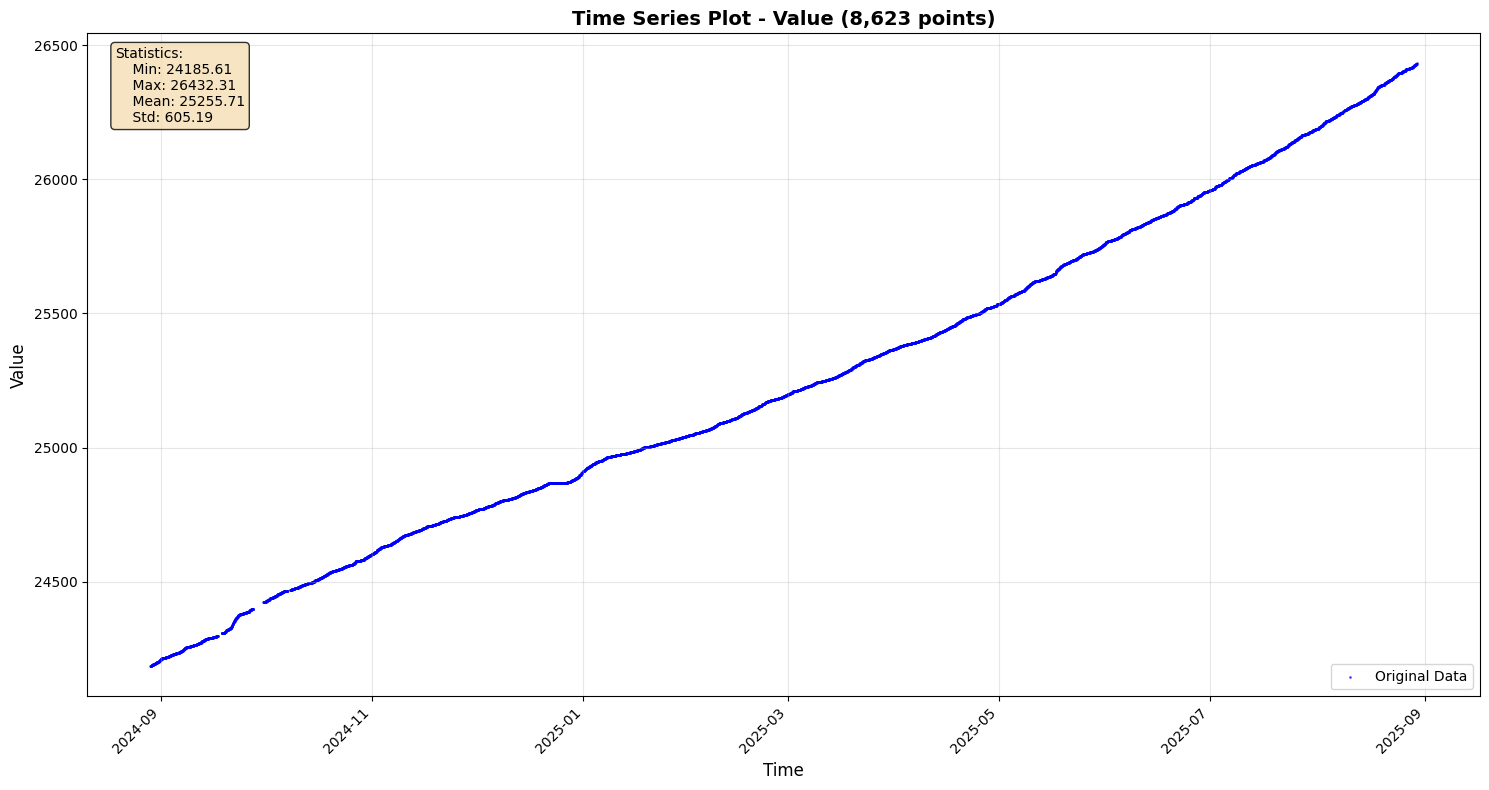

In [49]:
plot_timeseries(hourly_df, value_column="Value", plot_type="scatter")

Filtered to date range: 49 points


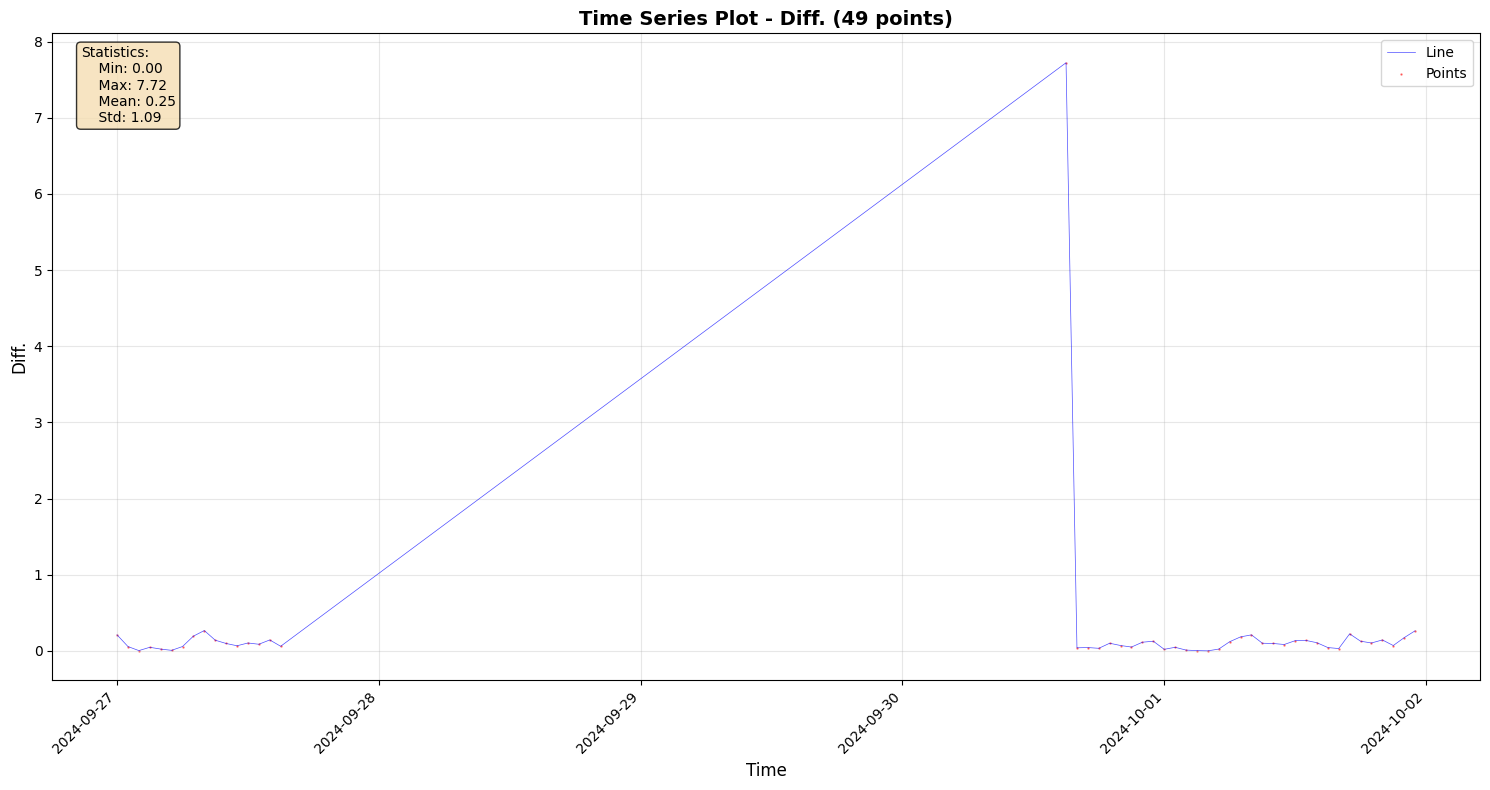

In [48]:
plot_timeseries(hourly_df, value_column="Diff.", date_range=("2024-09-27", "2024-10-1"), plot_type="both")

Filtered to date range: 120 points


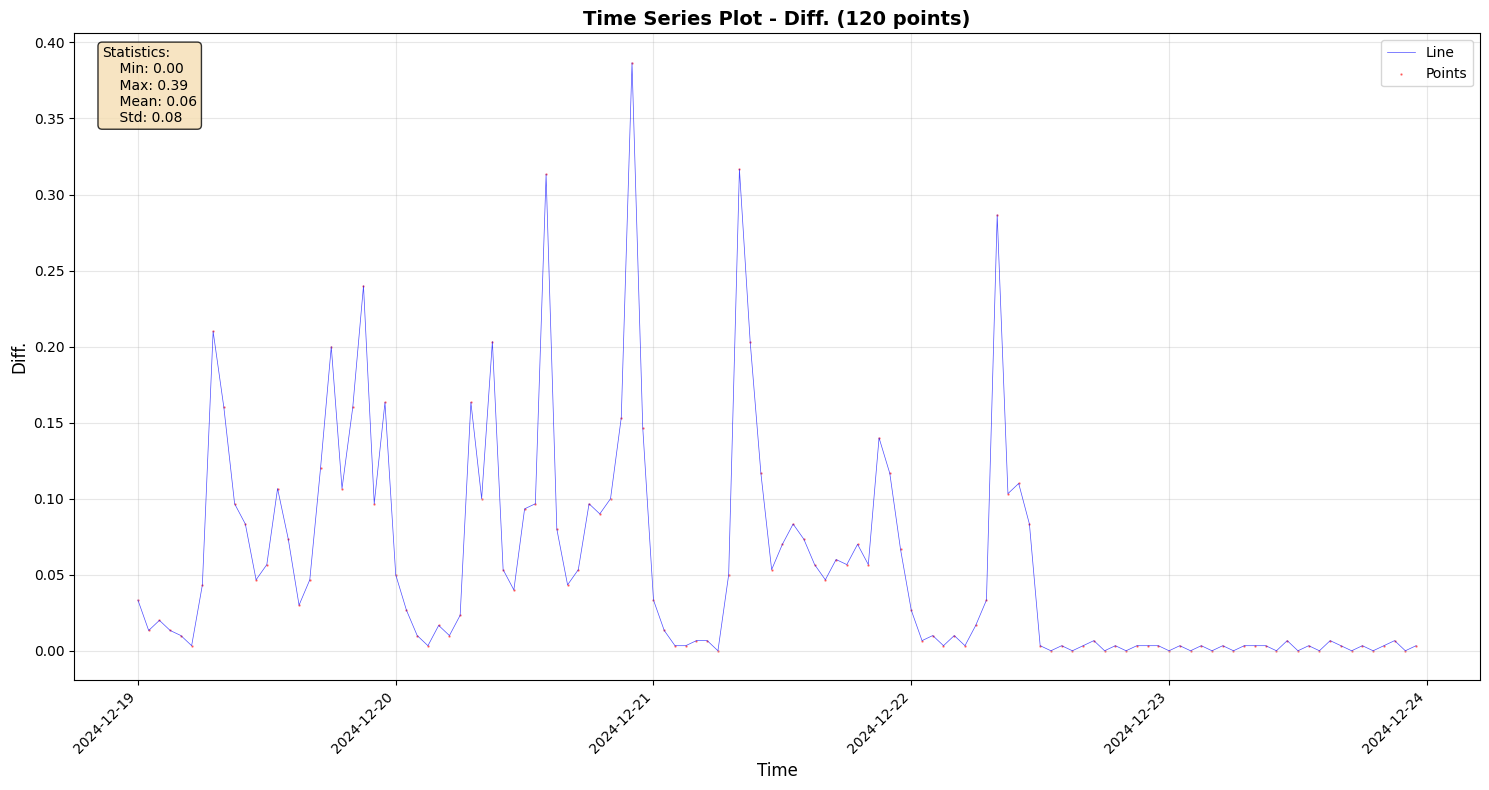

In [53]:
plot_timeseries(hourly_df, value_column="Diff.", date_range=("2024-12-19", "2024-12-23"), plot_type="both")

Filtered to date range: 360 points


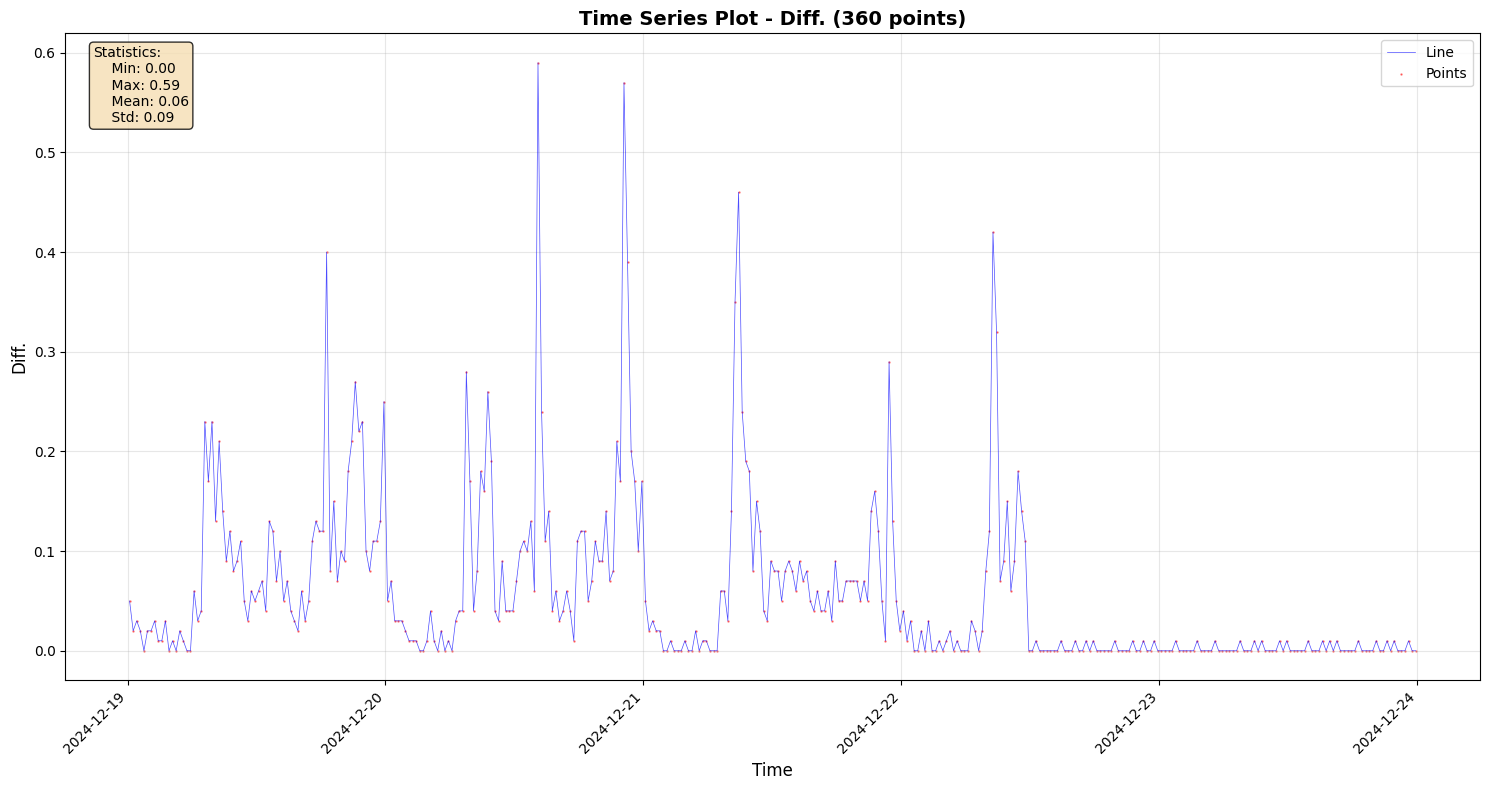

In [54]:
plot_timeseries(graph1, value_column="Diff.", date_range=("2024-12-19", "2024-12-23"), plot_type="both")

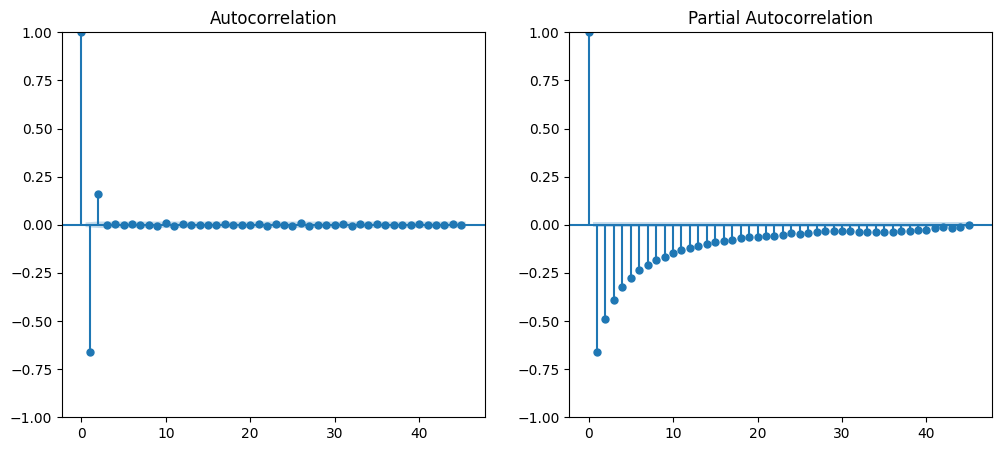

In [12]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(121)
plot_acf(graph1['Diff.'].diff().diff().dropna(), ax=plt.gca())  # diff if d=1
plt.subplot(122)
plot_pacf(graph1['Diff.'].diff().diff().dropna(), ax=plt.gca())
plt.show()

In [13]:
import pandas as pd
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fill_missing_timestamps_with_auto_arima_global(df, value_column, period_minutes=20, tolerance_minutes=5):
    """
    Fills missing timestamps in a time-indexed DataFrame using ARIMA forecasts.
    Each gap is filled in place so subsequent gaps use the imputed values.

    Args:
        df (pd.DataFrame): DataFrame with DateTimeIndex.
        value_column (str): Name of the value column to forecast.
        period_minutes (int): Expected time between readings (default 20).
        tolerance_minutes (int): Allowable tolerance for gaps (default 5).

    Returns:
        pd.DataFrame: DataFrame with missing timestamps filled.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame must have a DateTimeIndex")

    df_work = df.copy().sort_index()
    expected_period = pd.Timedelta(minutes=period_minutes)
    tolerance = pd.Timedelta(minutes=tolerance_minutes)
    gap_threshold = expected_period + tolerance

    # Step 1: Fit auto_arima on non-NaN values to get best order
    series_nonan = df_work[value_column].dropna()
    if len(series_nonan) < 10:
        print("Too few valid points to fit ARIMA. Returning original DataFrame.")
        return df_work

    print("Selecting best ARIMA model using auto_arima on full series...")
    try:
        auto_model = pm.auto_arima(
            series_nonan,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
            n_jobs=-1
        )
        best_order = auto_model.order
        print("Selected ARIMA order:", best_order)
    except Exception as e:
        print(f"Error fitting auto_arima: {e}")
        return df_work

    # Step 2: Identify gaps
    gap_threshold = expected_period + tolerance

    time_diffs = df_work.index.to_series().diff()
    gaps = time_diffs[time_diffs > gap_threshold]

    if gaps.empty:
        print("No significant gaps found.")
        return df_work

    total_filled = 0

    for gap_index, gap_duration in gaps.items():
        num_missing = int(gap_duration.total_seconds() / (period_minutes * 60)) - 1
        if num_missing <= 0:
            continue

        start_time = df_work.index[df_work.index.get_loc(gap_index) - 1]
        missing_times = pd.date_range(start=start_time + expected_period, periods=num_missing, freq=f"{period_minutes}min")

        # Step 3: Fit SARIMAX on data up to this gap (including previously imputed values)
        series_before_gap = df_work.loc[:start_time, value_column].dropna().astype(float)
        if series_before_gap.empty:
            print(f"Skipping gap at {start_time} — no valid data to forecast from.")
            continue

        try:
            model = SARIMAX(
                series_before_gap,
                order=best_order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fit = model.fit(disp=False)
            forecasted_values = fit.get_forecast(steps=num_missing).predicted_mean.values
        except Exception as e:
            print(f"Error forecasting gap at {start_time}: {e}")
            # fallback: fill with last known value
            forecasted_values = [series_before_gap.iloc[-1]] * num_missing

        # Step 4: Insert forecasted values directly into df_work
        gap_df = pd.DataFrame({value_column: forecasted_values}, index=missing_times)

        # Keep VAR_ID if present
        if "VAR_ID" in df_work.columns:
            gap_df["VAR_ID"] = df_work["VAR_ID"].iloc[0]

        df_work = pd.concat([df_work, gap_df]).sort_index()
        total_filled += num_missing
        print(f"Filled gap starting at {start_time} with {num_missing} timestamps with values {forecasted_values}")

    print(f"Successfully filled {total_filled} missing timestamps across {len(gaps)} gaps.")
    return df_work


In [14]:
import pandas as pd
import numpy as np

def _check_time_index(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a DatetimeIndex for time series imputation.")

import pandas as pd
import numpy as np

def _check_time_index(df):
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a DatetimeIndex for time series imputation.")

def create_missing_rows_and_interpolate(df, column, period_minutes=20, tolerance_minutes=5, method='time'):
    """
    1. Identify gaps in timestamps (missing sensor readings)
    2. Create rows for missing timestamps with NaN values  
    3. Interpolate the missing values
    4. Print detailed information about what was interpolated
    """
    _check_time_index(df)
    df_work = df.copy().sort_index()
    
    # Step 1: Define gap detection parameters
    expected_period = pd.Timedelta(minutes=period_minutes)
    tolerance = pd.Timedelta(minutes=tolerance_minutes)
    gap_threshold = expected_period + tolerance
    
    # Step 2: Identify gaps
    time_diffs = df_work.index.to_series().diff()
    gaps = time_diffs[time_diffs > gap_threshold]
    
    if gaps.empty:
        print("No significant gaps found.")
        # Still check for existing NaN values
        existing_nans = df_work[column].isna().sum()
        if existing_nans > 0:
            print(f"Found {existing_nans} existing NaN values to interpolate")
            df_work[column] = df_work[column].interpolate(method=method)
        return df_work
    
    print(f"Found {len(gaps)} gaps to fill")
    
    # Step 3: Create missing timestamp rows and track them
    new_rows = []
    added_timestamps = []
    total_filled = 0
    
    for gap_index, gap_duration in gaps.items():
        num_missing = int(gap_duration.total_seconds() / (period_minutes * 60)) - 1
        if num_missing <= 0:
            continue
            
        gap_loc = df_work.index.get_loc(gap_index)
        start_time = df_work.index[gap_loc - 1]
        
        missing_times = pd.date_range(
            start=start_time + expected_period, 
            periods=num_missing, 
            freq=f"{period_minutes}min"
        )
        
        print(f"Gap at {gap_index}: Adding {num_missing} timestamps between {start_time} and {gap_index}")
        
        for missing_time in missing_times:
            new_row = pd.Series(index=df_work.columns, dtype=float)
            new_row.name = missing_time
            new_row[column] = np.nan
            new_rows.append(new_row)
            added_timestamps.append(missing_time)
            
        total_filled += num_missing
    
    if new_rows:
        # Step 4: Add the new rows to the dataframe
        new_rows_df = pd.DataFrame(new_rows)
        df_complete = pd.concat([df_work, new_rows_df]).sort_index()
        print(f"✓ Added {total_filled} missing timestamps")
    else:
        df_complete = df_work
        added_timestamps = []
    
    # Step 5: Count NaN values before interpolation
    nan_count_before = df_complete[column].isna().sum()
    print(f"NaN values before interpolation: {nan_count_before}")
    
    # Step 6: Interpolate
    print(f"Applying {method} interpolation...")
    
    if method == 'time':
        df_complete[column] = df_complete[column].interpolate(method='time')
    elif method == 'cubic':
        df_complete[column] = df_complete[column].interpolate(method='cubic')
    elif method == 'spline':
        df_complete[column] = df_complete[column].interpolate(method='spline', order=3)
    elif method == 'linear':
        df_complete[column] = df_complete[column].interpolate(method='linear')
    else:
        raise ValueError("Method must be 'time', 'cubic', 'spline', or 'linear'")
    
    # Step 7: Count NaN values after interpolation
    nan_count_after = df_complete[column].isna().sum()
    interpolated_count = nan_count_before - nan_count_after
    
    print(f"NaN values after interpolation: {nan_count_after}")
    print(f"✓ Successfully interpolated {interpolated_count} values")
    
    # Step 8: Show interpolated values
    if added_timestamps:
        print(f"\n--- INTERPOLATED VALUES ---")
        print(f"{'Timestamp':<20} {'Interpolated Value':<20}")
        print("-" * 40)
        
        # Show first 10 interpolated values
        display_count = min(10, len(added_timestamps))
        for i, timestamp in enumerate(sorted(added_timestamps)[:display_count]):
            if timestamp in df_complete.index:
                value = df_complete.loc[timestamp, column]
                print(f"{timestamp.strftime('%Y-%m-%d %H:%M'):<20} {value:<20.3f}")
        
        if len(added_timestamps) > 10:
            print(f"... and {len(added_timestamps) - 10} more interpolated values")
            
        # Show some context around interpolated values
        print(f"\n--- SAMPLE CONTEXT (around first interpolated value) ---")
        if added_timestamps:
            sample_time = sorted(added_timestamps)[0]
            sample_idx = df_complete.index.get_loc(sample_time)
            
            # Show 2 values before and 2 after
            start_idx = max(0, sample_idx - 2)
            end_idx = min(len(df_complete), sample_idx + 3)
            
            context_slice = df_complete.iloc[start_idx:end_idx]
            print(f"{'Timestamp':<20} {'Value':<15} {'Status':<15}")
            print("-" * 50)
            
            for idx, (timestamp, row) in enumerate(context_slice.iterrows()):
                value = row[column]
                if timestamp in added_timestamps:
                    status = "INTERPOLATED"
                else:
                    status = "ORIGINAL"
                print(f"{timestamp.strftime('%Y-%m-%d %H:%M'):<20} {value:<15.3f} {status}")
    
    # Ensure non-negative values
    df_complete[column] = df_complete[column].clip(lower=0)
    
    print(f"\n✓ Final DataFrame: {len(df_complete)} rows (was {len(df_work)})")
    
    return df_complete


# Simpler function if you just want to add missing timestamps without interpolation
def add_missing_timestamps(df, column, period_minutes=20, tolerance_minutes=5):
    """
    Just add missing timestamp rows with NaN values (no interpolation).
    Then you can use standard pandas interpolate methods.
    """
    df_with_gaps = create_missing_rows_and_interpolate(
        df, column, period_minutes, tolerance_minutes, method='linear'
    )
    # Reset the values to NaN so you can choose your own interpolation
    time_diffs = df.index.to_series().diff()
    gaps = time_diffs[time_diffs > pd.Timedelta(minutes=period_minutes + tolerance_minutes)]
    
    # Mark newly added rows as NaN
    original_index = set(df.index)
    for idx in df_with_gaps.index:
        if idx not in original_index:
            df_with_gaps.loc[idx, column] = np.nan
            
    return df_with_gaps


Found 556 gaps to fill
Gap at 2024-08-29 10:32:00: Adding 1 timestamps between 2024-08-29 09:52:00 and 2024-08-29 10:32:00
Gap at 2024-08-30 09:52:00: Adding 10 timestamps between 2024-08-30 06:12:00 and 2024-08-30 09:52:00
Gap at 2024-08-30 22:12:00: Adding 1 timestamps between 2024-08-30 21:32:00 and 2024-08-30 22:12:00
Gap at 2024-08-31 06:12:00: Adding 1 timestamps between 2024-08-31 05:32:00 and 2024-08-31 06:12:00
Gap at 2024-08-31 11:52:00: Adding 1 timestamps between 2024-08-31 11:12:00 and 2024-08-31 11:52:00
Gap at 2024-09-02 08:52:00: Adding 1 timestamps between 2024-09-02 08:12:00 and 2024-09-02 08:52:00
Gap at 2024-09-02 09:52:00: Adding 1 timestamps between 2024-09-02 09:12:00 and 2024-09-02 09:52:00
Gap at 2024-09-03 07:31:59: Adding 1 timestamps between 2024-09-03 06:51:59 and 2024-09-03 07:31:59
Gap at 2024-09-03 14:31:59: Adding 1 timestamps between 2024-09-03 13:51:59 and 2024-09-03 14:31:59
Gap at 2024-09-07 13:11:59: Adding 1 timestamps between 2024-09-07 12:31:59 

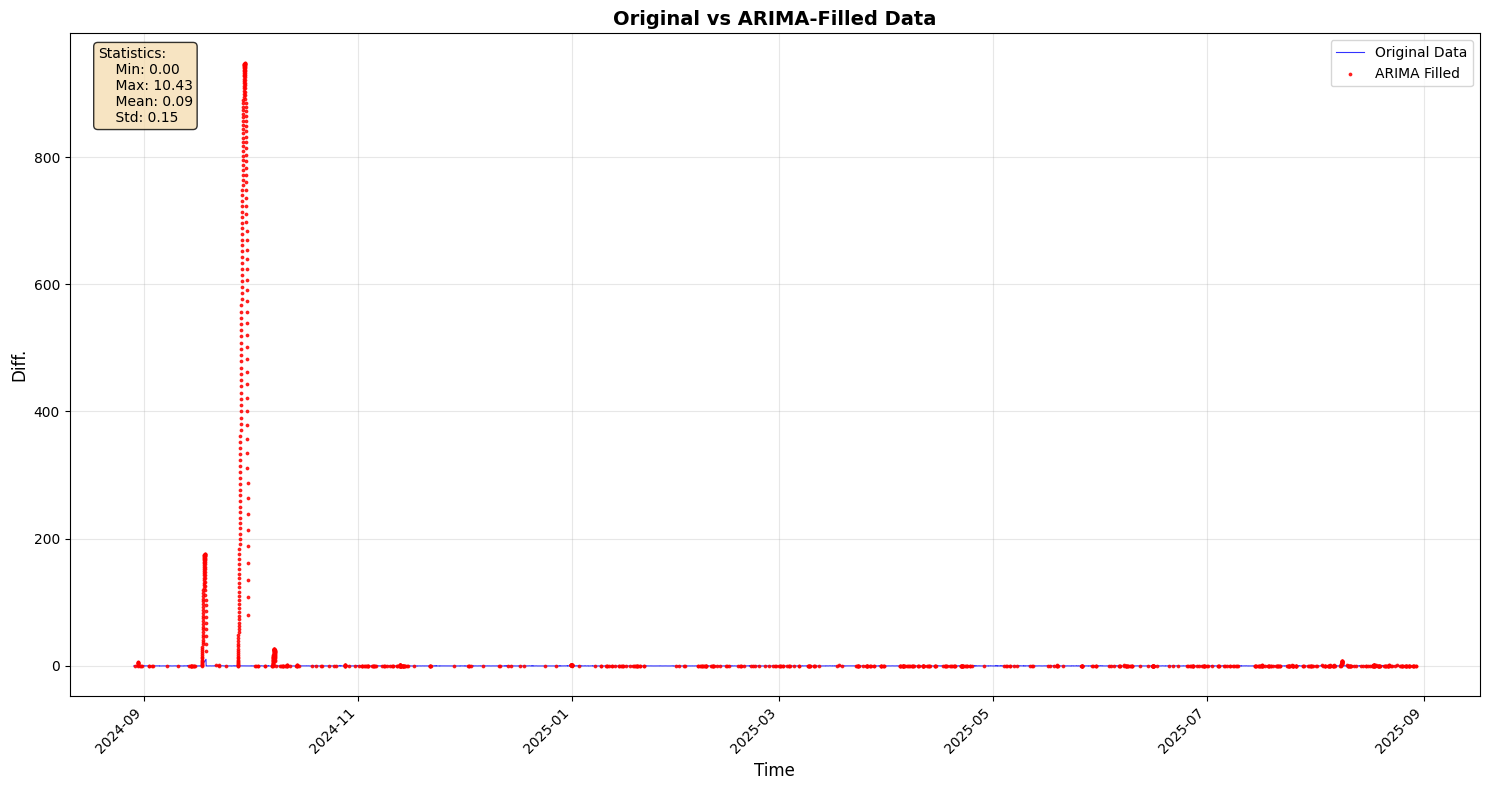

In [15]:
graph1_filled = create_missing_rows_and_interpolate(graph1, "Diff.", method="cubic")
# Compare original vs filled data
#fig = detailed_plot(graph1)
#fig2 = detailed_plot(graph1_filled)
fig = compare_before_after(graph1, graph1_filled)
plt.show()